In [1]:
import pandas as pd  
import numpy as np   
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
from matplotlib import rc
rc('font', family='Malgun Gothic')

In [2]:
# seoul1 = pd.read_csv("./data/일반음식점(서울시).csv", encoding="cp949", encoding_errors="replace", low_memory=False)
# seoul2 = pd.read_csv("./data/휴게음식점(서울시).csv", encoding="cp949", encoding_errors="replace", low_memory=False)
# seoul3 = pd.read_csv("./data/제과점영업(서울시).csv", encoding="cp949", low_memory=False)

# seoul = pd.concat([seoul1, seoul2, seoul3], ignore_index=True)
# seoul.to_csv("./data/Seoul_all_utf8.csv", index=False, encoding="utf-8-sig")

In [3]:
# seongdong1 = pd.read_csv("./data/일반음식점(성동구).csv", encoding="cp949")
# seongdong2 = pd.read_csv("./data/휴게음식점(성동구).csv", encoding="cp949")
# seongdong3 = pd.read_csv("./data/제과점영업(성동구).csv", encoding="cp949")

# seongdong = pd.concat([seongdong1, seongdong2, seongdong3], ignore_index=True)
# seongdong.to_csv("./data/Seongdong_all_utf8.csv", index=False, encoding="utf-8-sig")

In [5]:
seoul = pd.read_csv("./data/Seoul.csv")
seongdong = pd.read_csv("./data/Seongdong.csv")

display(seoul.tail(2))
display(seongdong.tail(2))

C:\Users\Administrator\AppData\Local\Temp;\ipykernel_20468\671572824.py:1: DtypeWarning: Columns (36,41,42,43) have mixed types. Specify dtype option on import or set low_memory=False.
  seoul = pd.read_csv("./data/Seoul.csv")


,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,휴업시작일자,...,공장판매직종업원수,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지
681785,3240000,3240000-121-1991-04880,1991-01-07,NaN,3,폐업,2,폐업,1997-11-27,NaN,...,NaN,NaN,NaN,NaN,NaN,N,41.28,NaN,NaN,NaN
681786,3240000,3240000-121-1987-04775,1987-10-17,NaN,3,폐업,2,폐업,2008-07-11,NaN,...,NaN,NaN,NaN,NaN,NaN,N,23.52,NaN,NaN,NaN


,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,휴업시작일자,...,공장판매직종업원수,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지
18867,3030000,3030000-121-2025-00030,2025-09-22,NaN,3,폐업,2,폐업,2025-09-26,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18868,3030000,3030000-121-2025-00031,2025-09-22,NaN,1,영업/정상,1,영업,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 불필요한 인덱스 컬럼 제거 + 날짜형 변환
def tidy(df):
    drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    for col in ["인허가일자", "폐업일자"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col].astype(str), errors="coerce")
    return df

seoul = tidy(seoul)
seongdong = tidy(seongdong)

# 월별 집계 / 폐업률 계산
def monthly_counts(df, date_col, start="2000-01-01", end=None):
    if date_col not in df.columns:
        return pd.Series(dtype="int64", name=date_col)
    s = df[date_col].dropna()
    if start:
        s = s[s >= pd.Timestamp(start)]
    if end:
        s = s[s < pd.Timestamp(end)]
    if s.empty:
        return pd.Series(dtype="int64", name=date_col)
    return (s.to_frame(name=date_col).set_index(date_col)
              .assign(n=1)["n"].resample("MS").sum())

def open_close_series(df, start="2000-01-01", end=None):
    open_m  = monthly_counts(df, "인허가일자", start, end)
    close_m = monthly_counts(df, "폐업일자", start, end)
    return open_m, close_m

def closing_rate(open_m, close_m):
    idx = open_m.index.union(close_m.index)
    o = open_m.reindex(idx, fill_value=0)
    c = close_m.reindex(idx, fill_value=0)
    denom = o + c
    rate = (c / denom.replace(0, pd.NA)).fillna(0.0).rename("폐업률")
    return rate

In [11]:
PALETTE = {"open":"#2C9E58", "close":"#D66E7C", 
           "seoul":"#FDA635", "seongdong":"#227FB4"}

def plot_open_close(df, region_name, start="2000-01-01", end=None):
    o, c = open_close_series(df, start, end)
    oma, cma = o.rolling(3, min_periods=1).mean(), c.rolling(3, min_periods=1).mean()

    plt.figure(figsize=(14,5))
    # 월별(점선)
    o.plot(label=f"{region_name} 개업(월)", linestyle='-', linewidth=1.5, color=PALETTE["open"])
    c.plot(label=f"{region_name} 폐업(월)", linestyle='-', linewidth=1.5, color=PALETTE["close"])
    # 3개월 MA(실선)
    oma.plot(label=f"{region_name} 개업 3개월 MA", linestyle='--', linewidth=1, color=PALETTE["open"])
    cma.plot(label=f"{region_name} 폐업 3개월 MA", linestyle='--', linewidth=1, color=PALETTE["close"])

    ttl_range = f"{pd.to_datetime(start).date()}~현재" if end is None else f"{pd.to_datetime(start).date()}~{pd.to_datetime(end).date()}"
    plt.title(f"{region_name} · 개업/폐업 월별 추세 ({ttl_range})")
    plt.xlabel("월"); plt.ylabel("가게 수"); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

def plot_closing_rate_compare(seoul_df, sd_df, start="2000-01-01", end=None):
    so, sc = open_close_series(seoul_df, start, end)
    do, dc = open_close_series(sd_df, start, end)
    s_rate, d_rate = closing_rate(so, sc), closing_rate(do, dc)
    sma, dma = s_rate.rolling(3, min_periods=1).mean(), d_rate.rolling(3, min_periods=1).mean()

    plt.figure(figsize=(14,5))
    # 월별(점선)
    s_rate.plot(label="서울 폐업률(월)", linestyle='-', linewidth=1.5, color=PALETTE["seoul"])
    d_rate.plot(label="성동 폐업률(월)", linestyle='-', linewidth=1.5, color=PALETTE["seongdong"])
    # 3개월 MA(실선)
    sma.plot(label="서울 폐업률 3개월 MA", linestyle='--', linewidth=1, color=PALETTE["seoul"])
    dma.plot(label="성동 폐업률 3개월 MA", linestyle='--', linewidth=1, color=PALETTE["seongdong"])

    ttl_range = f"{pd.to_datetime(start).date()}~현재" if end is None else f"{pd.to_datetime(start).date()}~{pd.to_datetime(end).date()}"
    plt.title(f"서울 vs 성동 · 폐업률 비교 ({ttl_range})  [폐업률 = 폐업 / (개업+폐업)]")
    plt.xlabel("월"); plt.ylabel("폐업률"); plt.ylim(0, 1); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

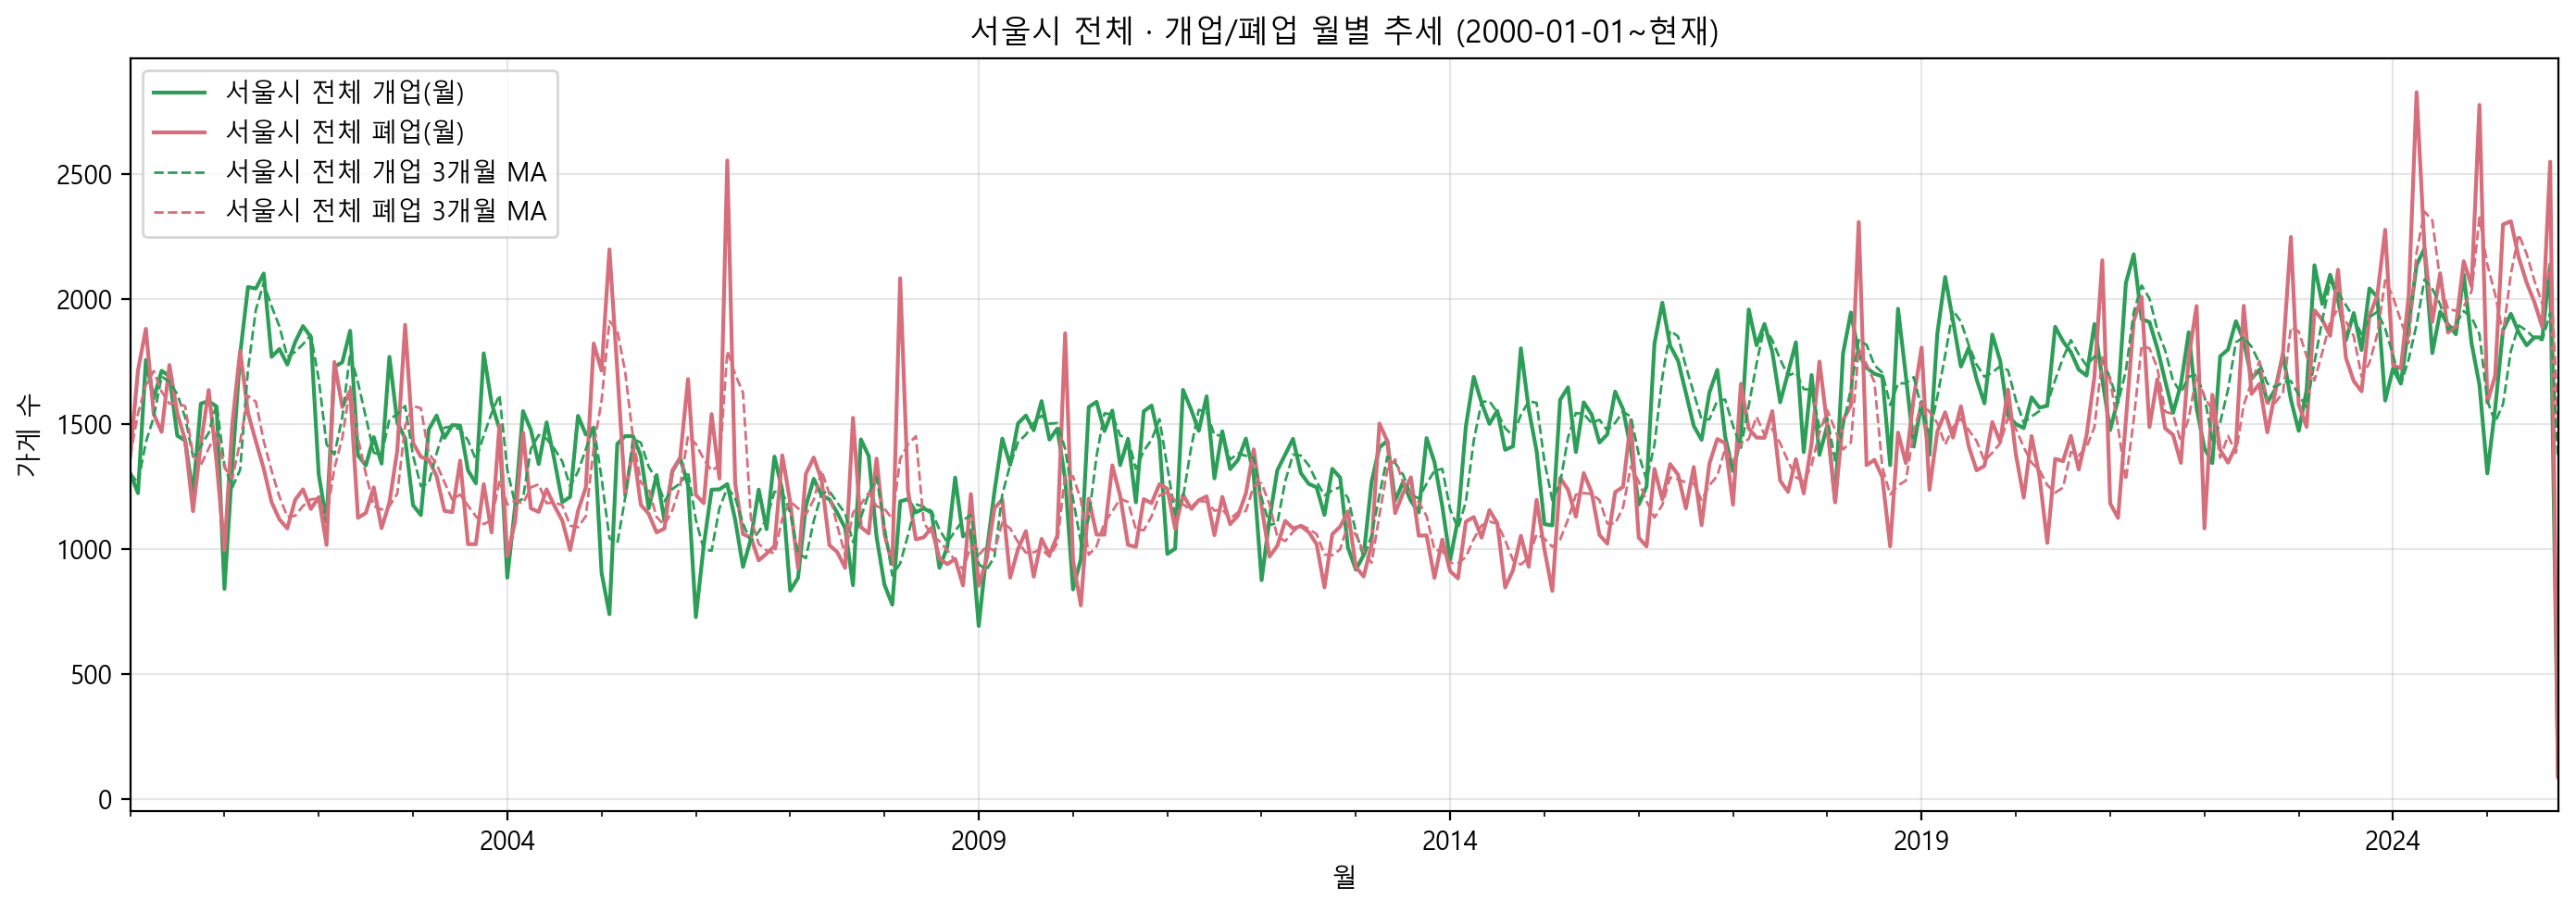

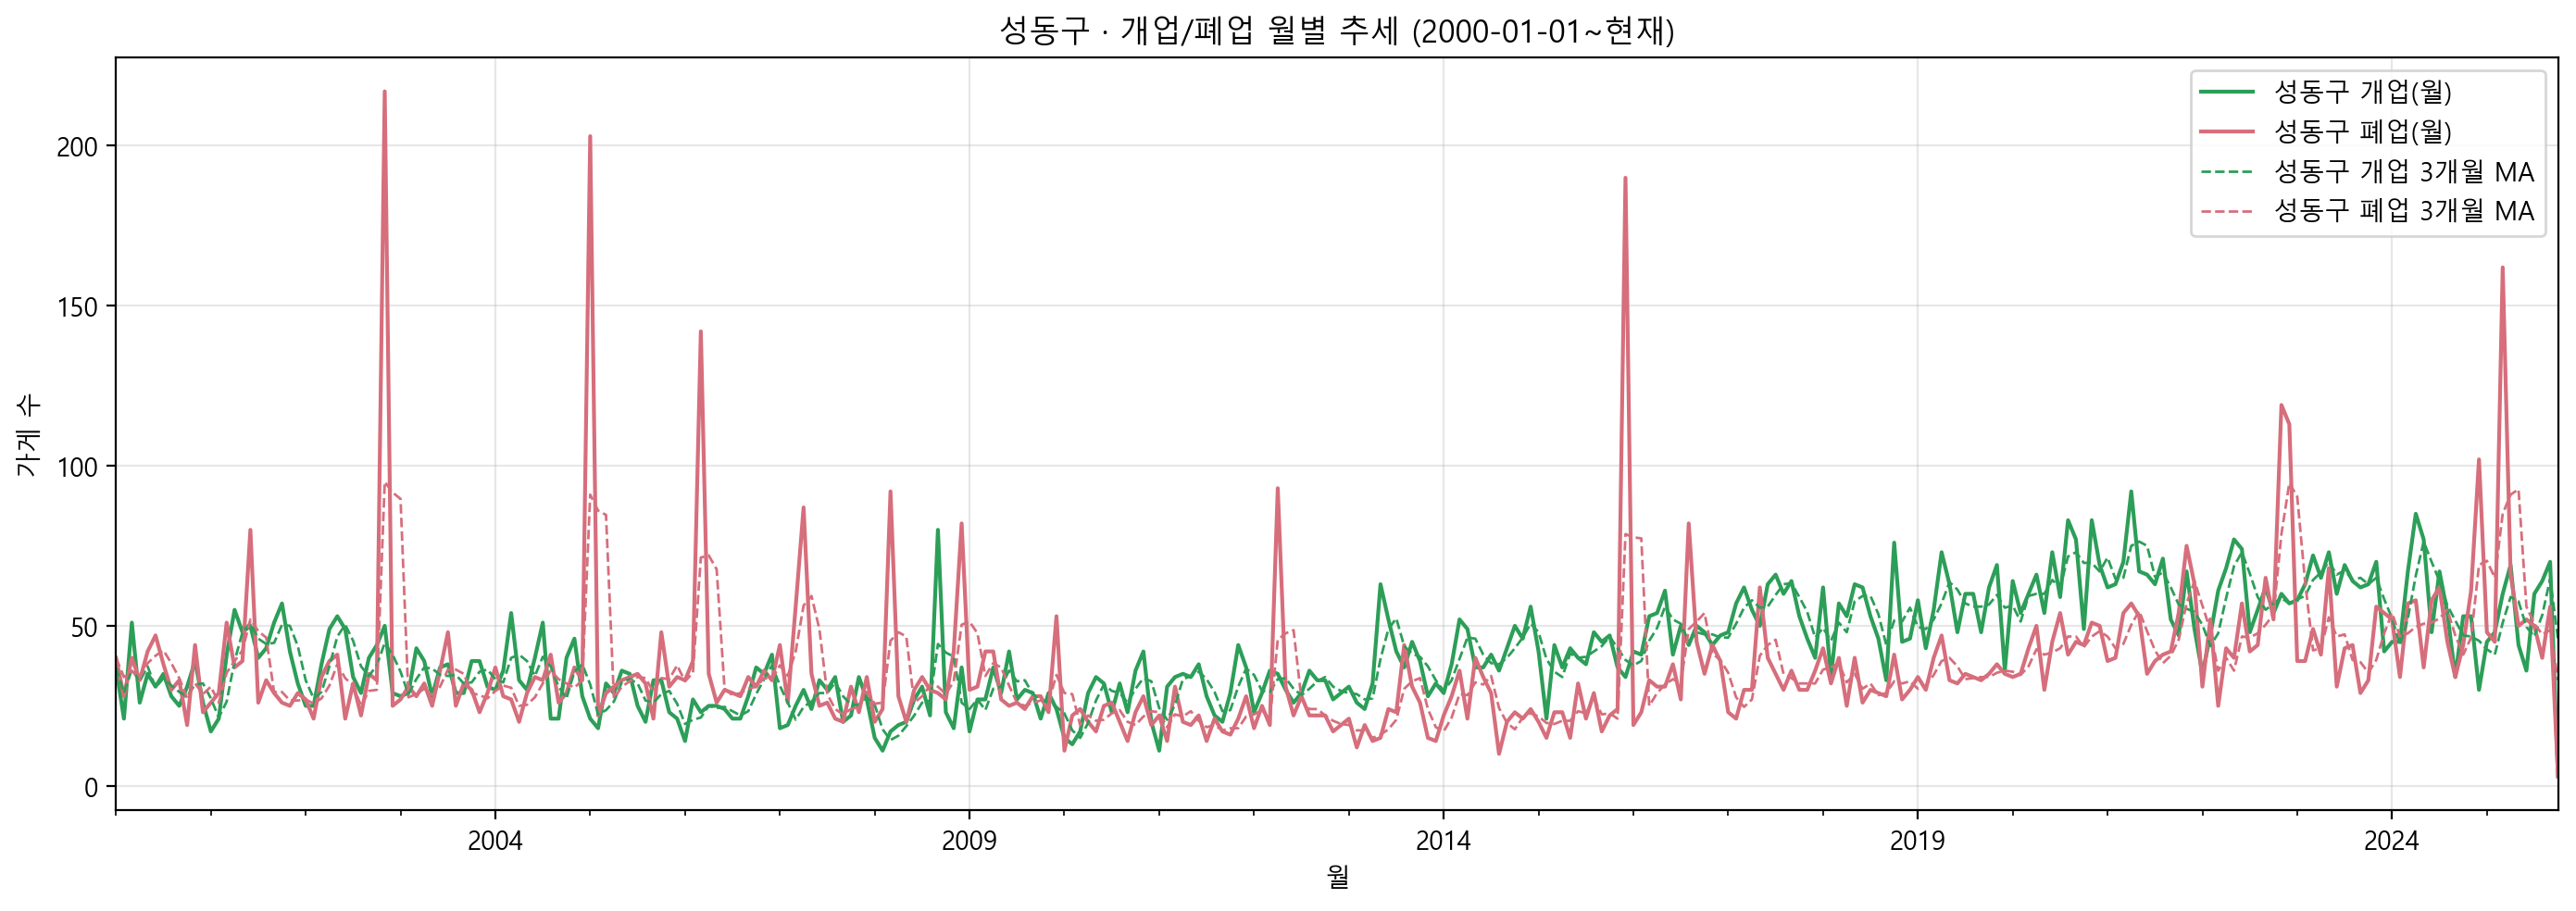

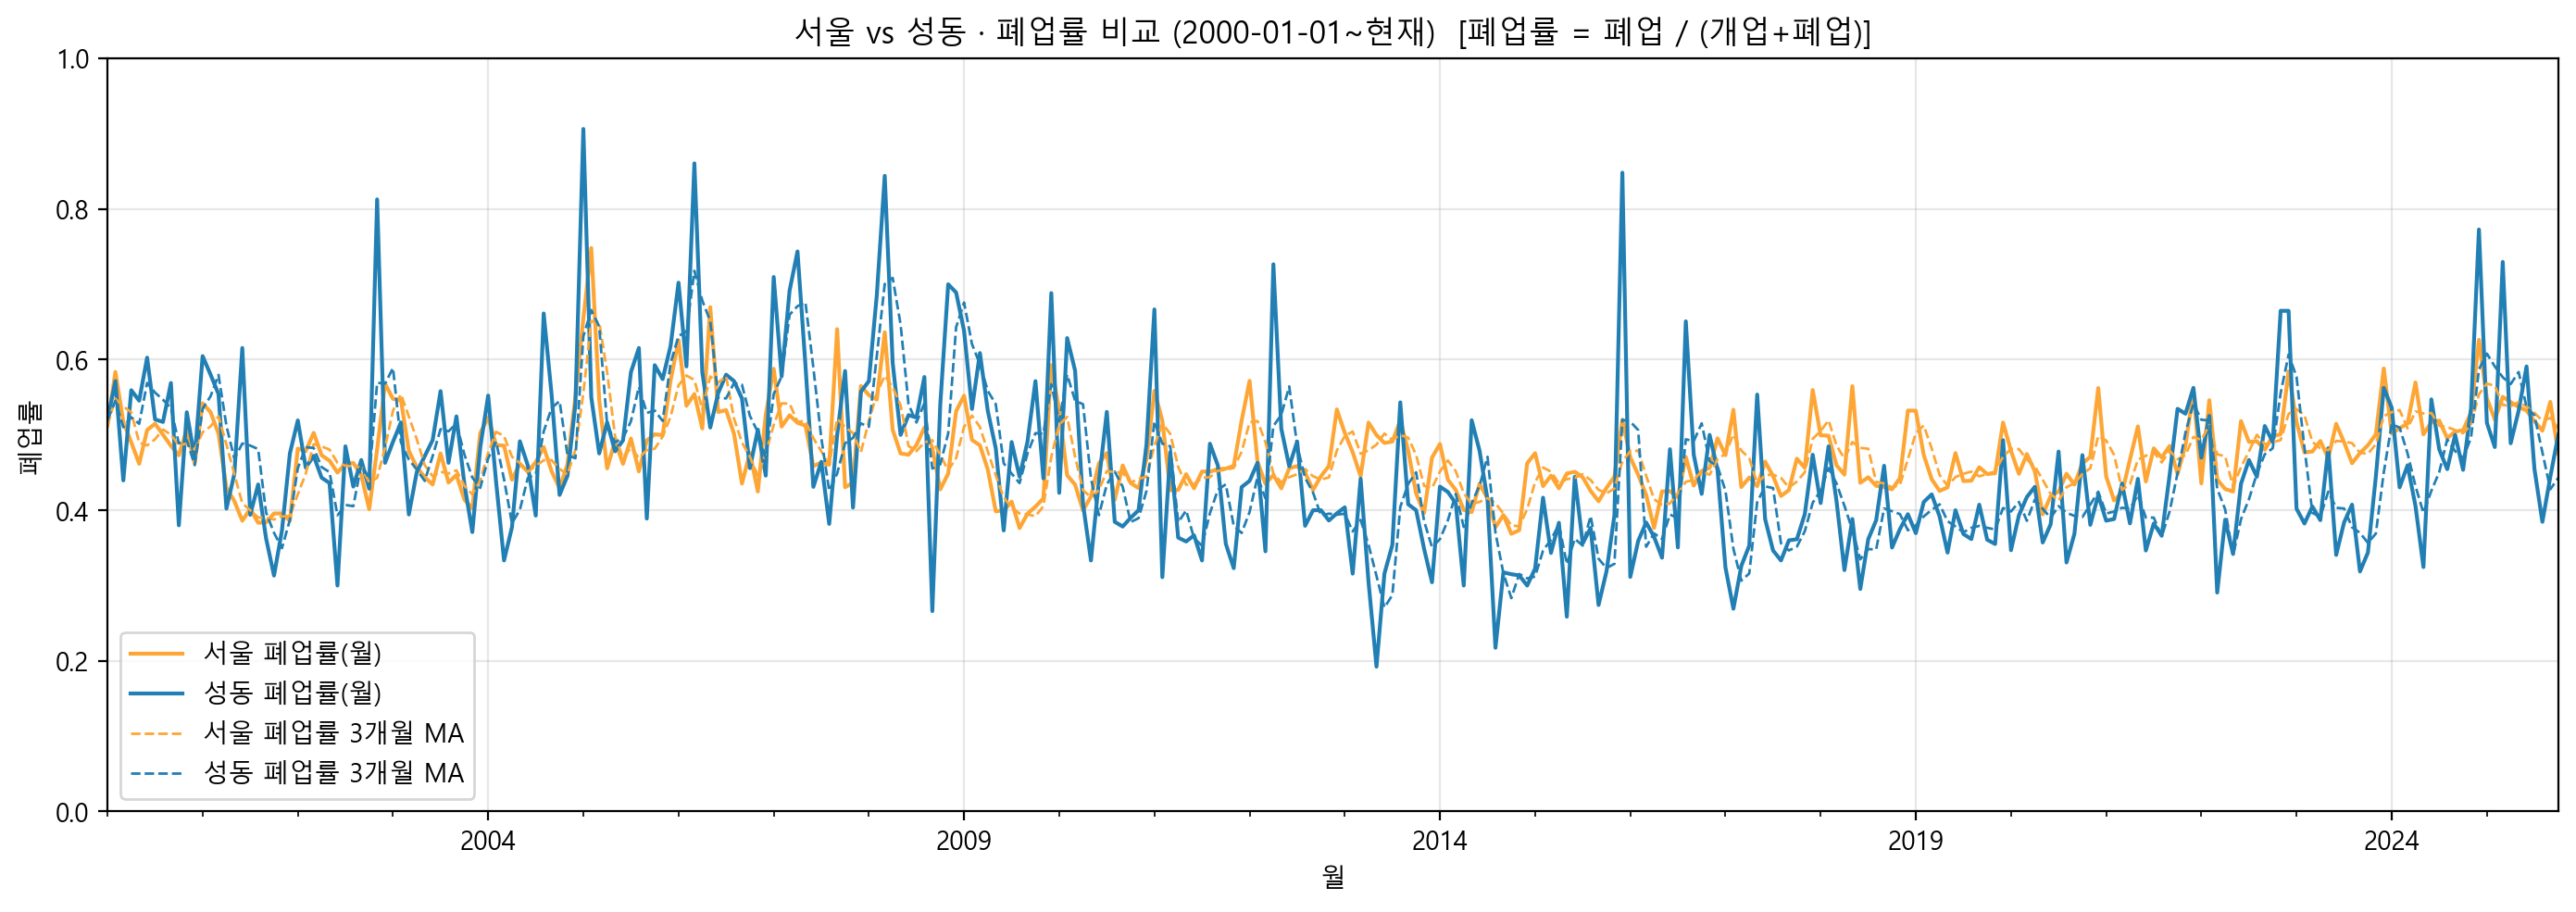

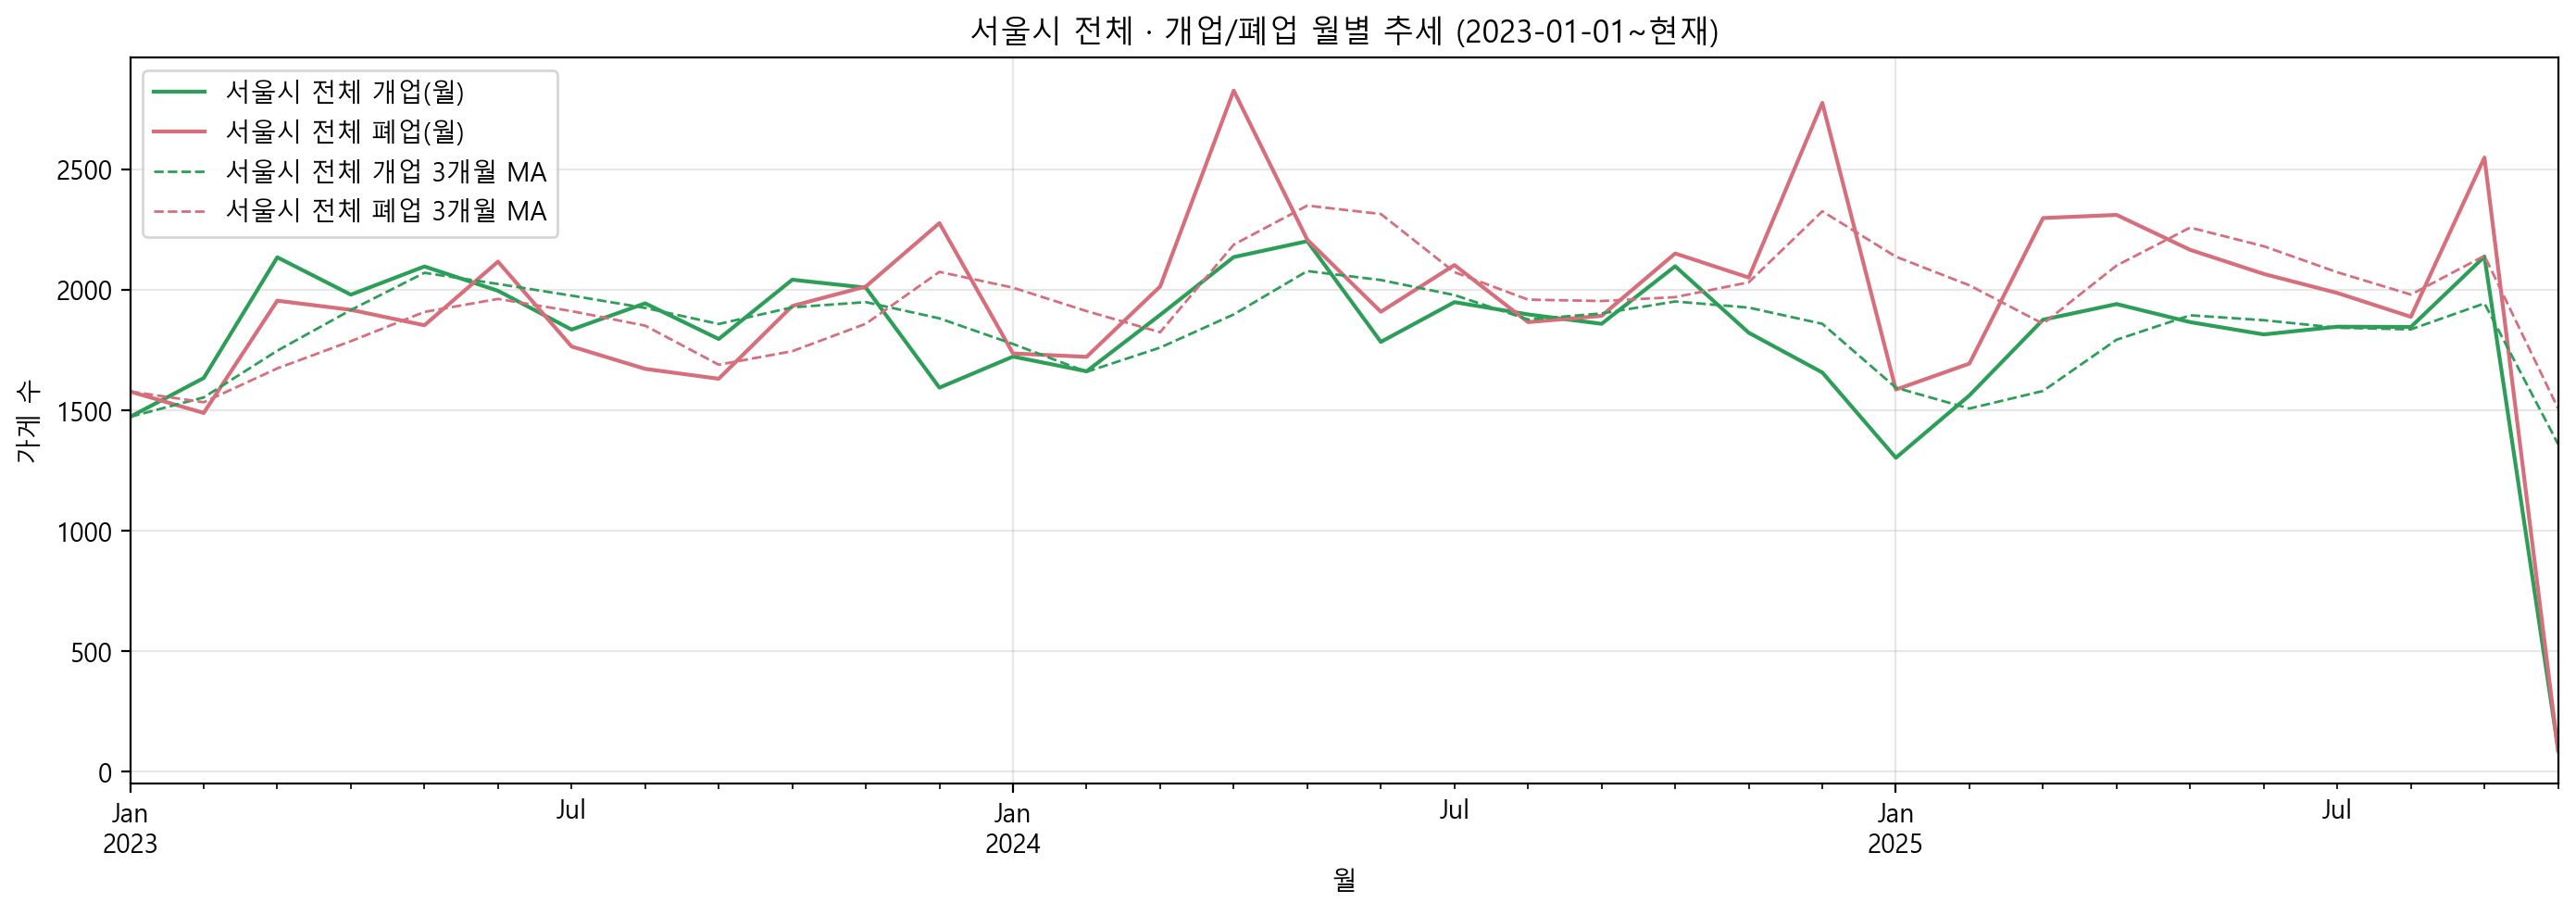

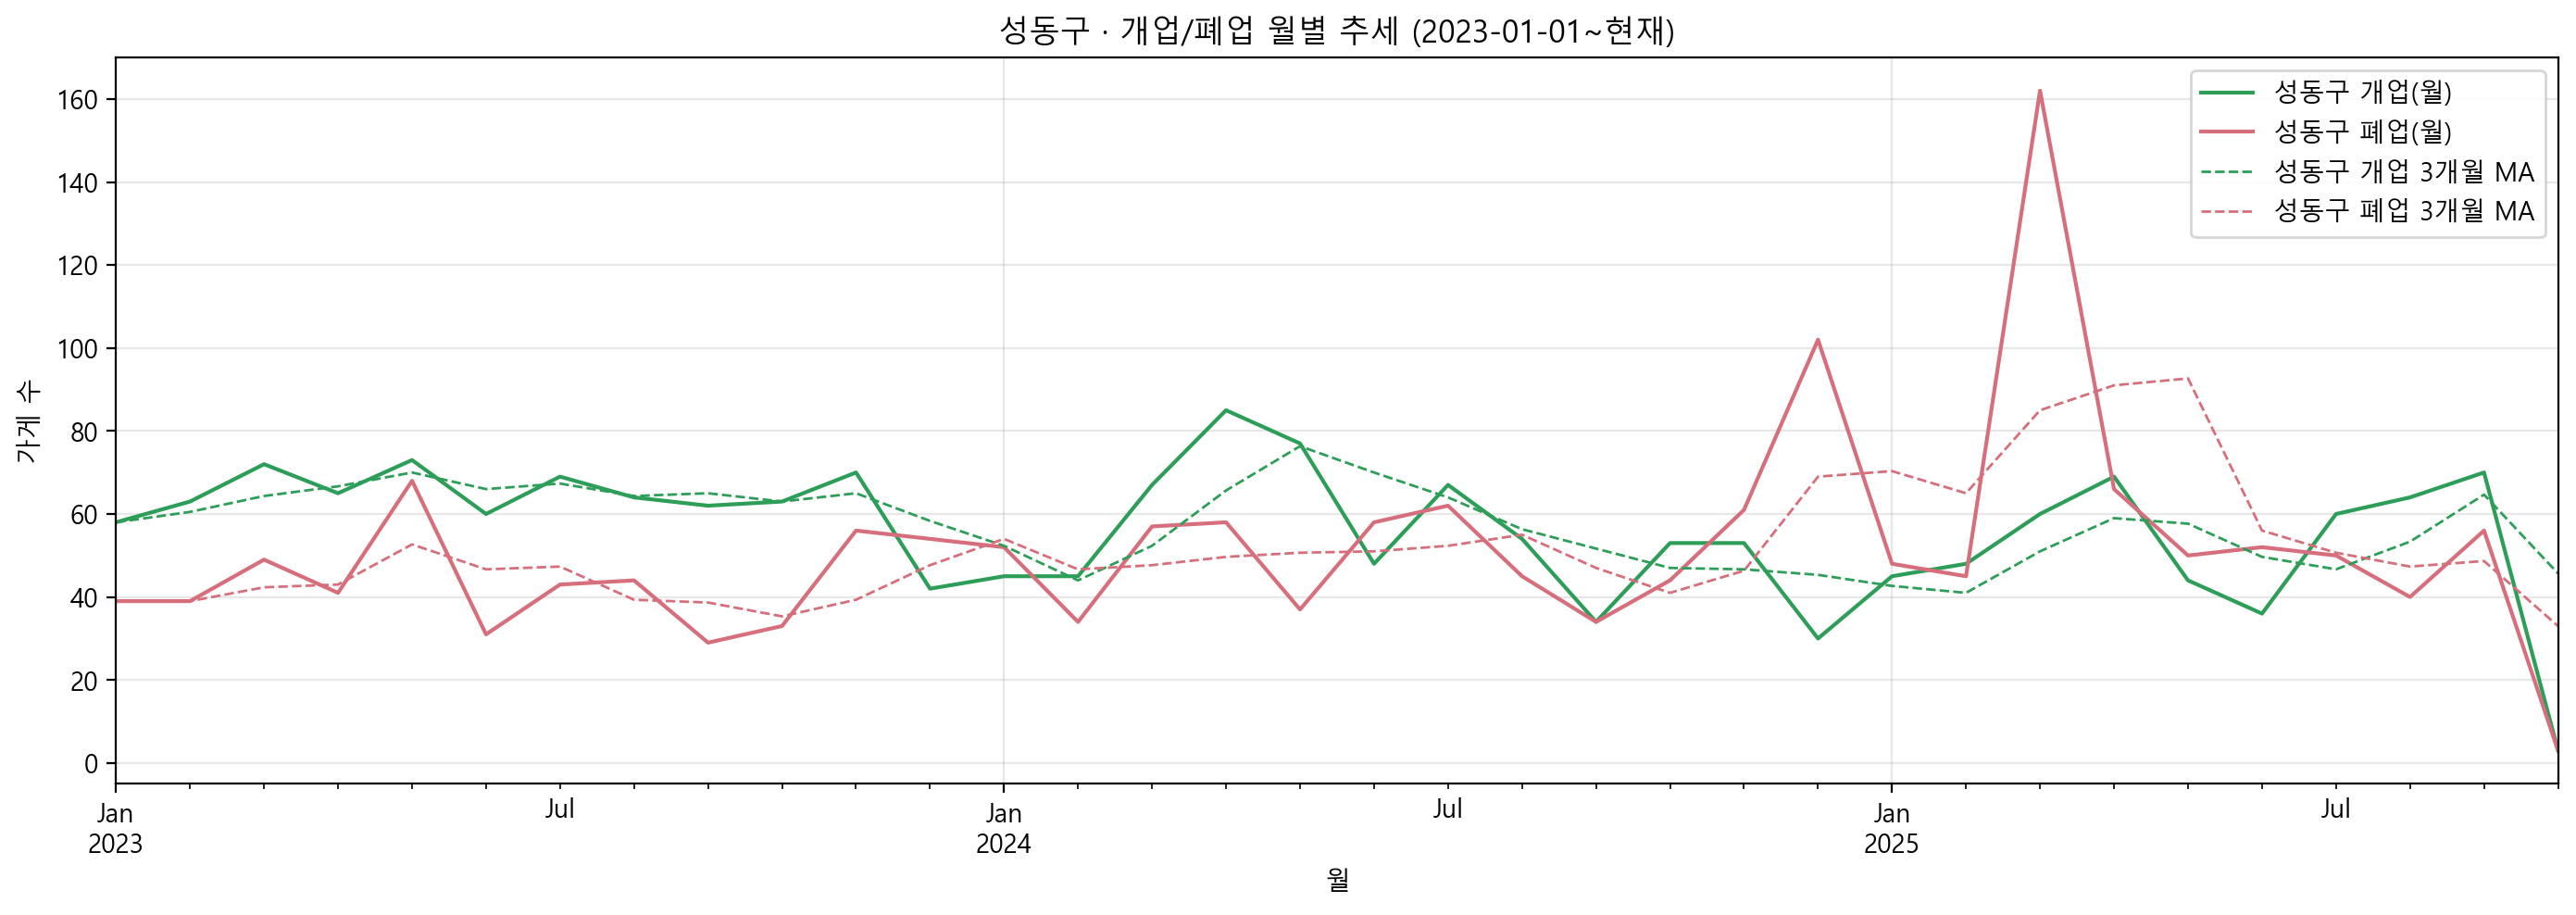

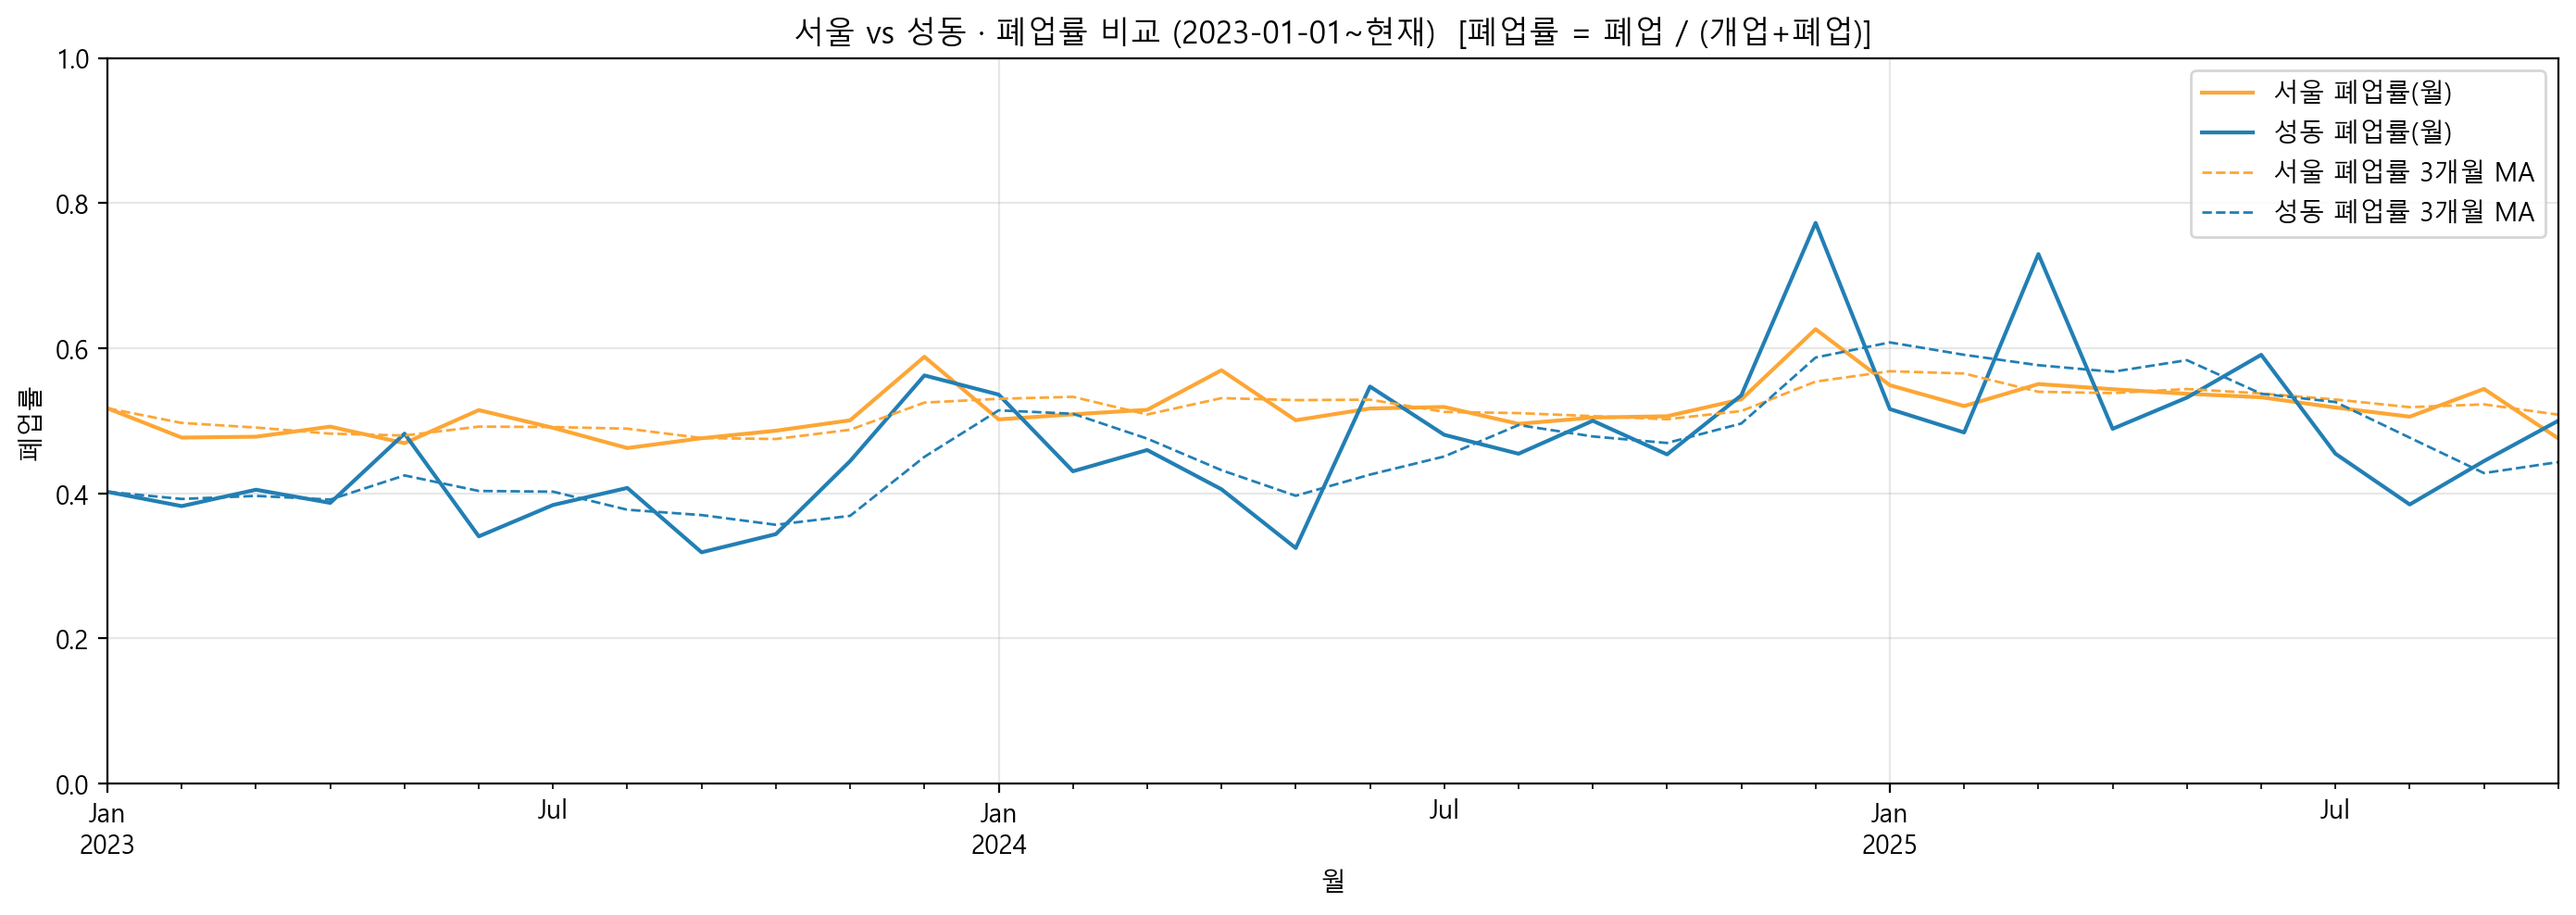

In [ ]:
# 서울/성동 개별
plot_open_close(seoul, "서울시 전체", start="2000-01-01")
plot_open_close(seongdong, "성동구", start="2000-01-01")

# 폐업률 비교
plot_closing_rate_compare(seoul, seongdong, start="2000-01-01")

# 2023년 이후
plot_open_close(seoul, "서울시 전체", start="2023-01-01")
plot_open_close(seongdong, "성동구", start="2023-01-01")
plot_closing_rate_compare(seoul, seongdong, start="2023-01-01")